# 🎯 Person Re-ID — FastReID + FAISS + IoU Tracker (Optimised)
**Pipeline:** YOLOv8 → Simple IoU Tracker → FastReID Embeddings → FAISS Re-ID

### ✅ What's improved in this version
- 🚀 **YOLO loaded once** — not 700× during search (saves ~40 min)
- 🚀 **Fast TTA mode** for search (2 augments instead of 10 — 5× faster)
- 🚀 **yolov8n during search**, yolov8m for final run only
- 🚀 **frame_skip ≥ 3 enforced during search** (fewer frames = faster)
- 🚀 **Batched GPU inference** — all crops in one forward pass per frame
- 🚀 **Half-precision (fp16)** inference on GPU (2× throughput)
- 🧠 **Ghost/phantom person fix** — higher conf_thr + stricter NMS + min area filter
- 🧠 **Better score function** — penalises inflated person counts
- 🧠 **NMS on detections** before tracking to kill duplicate boxes
- 🧠 **Max active persons cap** — rejects new registrations when count exceeds expected
- 🔒 **Aspect-ratio + area hard gates** on crops (tighter than before)

> ⚡ Enable GPU: Runtime → Change runtime type → T4 GPU

## 📦 Cell 1 — Install Dependencies

In [1]:
# Install all required packages
!pip install -q ultralytics
!pip install -q faiss-gpu 2>/dev/null || pip install -q faiss-cpu
!pip install -q gdown yacs termcolor tabulate timm

print('✅ All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 223.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.3 MB/s eta 0:00:00
✅ All packages installed.


## 🔧 Cell 2 — Imports & Constants

In [2]:
import cv2
import os
import gc
import random
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from collections import defaultdict
from pathlib import Path
from IPython.display import display, clear_output
import torch
import torch.nn.functional as F

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ─── CONSTANTS ───────────────────────────────────────────────────────────────
EMBEDDING_DIM         = 2048    # ResNet-50 output dim

# Gallery / EMA
MAX_EMBS_PER_PERSON   = 20
EMA_ALPHA             = 0.90

# Diversity (prevent storing nearly-identical embeddings)
DIVERSITY_MIN_DIST    = 0.08

# Recently-lost re-entry window
RECENTLY_LOST_WINDOW  = 12000
RECENTLY_LOST_THR     = 0.60
RECENTLY_LOST_TOP_K   = 20

# Zone / event logic
STABLE_ZONE_FRAMES    = 4
EVENT_COOLDOWN        = 60

# Periodic identity merge
MERGE_INTERVAL        = 300
MERGE_SIM_THRESHOLD   = 0.90

# Re-ID upgrade gap (how much better a new match must be to replace current ID)
IDENTITY_UPGRADE_GAP  = 0.25

# ── Crop quality gates ────────────────────────────────────────────────────────
# Tighter than original to kill partial / tiny detections
MIN_CROP_H            = 90      # was 80
MIN_CROP_W            = 45      # was 40
MIN_CROP_AREA         = 5000    # new: absolute pixel area gate
CROP_ASPECT_MIN       = 1.5     # was 1.4
CROP_ASPECT_MAX       = 5.0     # was 5.5

# Detection quality gates for EMA update
MIN_DET_CONF_STORE    = 0.55    # was 0.52
MIN_DET_CONF_EMA      = 0.40    # was 0.35

# Ghost / phantom guards
GHOST_RATIO_TRIGGER   = 1.5
POSITION_PENALTY_DIST = 220
POSITION_PENALTY_W    = 0.82

# ── NEW: hard cap on how many unique persons can exist in a short clip ─────────
# Set this to ~2x the true number of people in your scene.
# E.g. 4 real people → set MAX_PERSONS_EXPECTED = 8
# This stops the pipeline from accumulating phantom IDs indefinitely.
MAX_PERSONS_EXPECTED  = 8       # ← TUNE THIS for your video

# NMS IoU threshold applied to raw YOLO detections (kills duplicate boxes)
DETECTION_NMS_IOU     = 0.50

CROWD_THRESHOLD       = 5
REEVAL_INTERVAL       = 25

print('✅ Constants loaded.')
print(f'   MAX_PERSONS_EXPECTED = {MAX_PERSONS_EXPECTED}  (set to ~2× real persons in scene)')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
✅ Constants loaded.
   MAX_PERSONS_EXPECTED = 8  (set to ~2× real persons in scene)


## 🧠 Cell 3 — Load FastReID Model
ResNet-50 backbone, fp16 on GPU for 2× throughput.

In [3]:
import torchvision.models as tv_models
import torchvision.transforms as T
from PIL import Image

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
USE_FP16 = torch.cuda.is_available()   # half-precision on GPU only
print(f'Loading FastReID backbone on {DEVICE}  (fp16={USE_FP16})...')


class FastReIDExtractor(torch.nn.Module):
    """
    ResNet-50 backbone → GlobalAvgPool → L2-normalised 2048-d embedding.
    Runs in eval mode with no_grad; fp16 on GPU for 2× throughput.
    """
    def __init__(self, pretrained: bool = True):
        super().__init__()
        backbone = tv_models.resnet50(
            weights=tv_models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        self.features = torch.nn.Sequential(*list(backbone.children())[:-1])
        self.eval()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            feat = self.features(x)       # (B, 2048, 1, 1)
            feat = feat.flatten(1)        # (B, 2048)
            feat = F.normalize(feat, p=2, dim=1)
        return feat


# Standard ReID normalisation (ImageNet stats)
_REID_TRANSFORM = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std =[0.229, 0.224, 0.225]),
])

REID_MODEL = FastReIDExtractor(pretrained=True).to(DEVICE)
REID_MODEL.eval()
if USE_FP16:
    REID_MODEL = REID_MODEL.half()

print(f'✅ FastReID extractor ready on {DEVICE} (fp16={USE_FP16}).')

# ── Optional: load a pretrained Re-ID checkpoint (.pth) ──────────────────────
# FASTREID_WEIGHTS = '/content/market_bot_R50.pth'
# if os.path.exists(FASTREID_WEIGHTS):
#     state = torch.load(FASTREID_WEIGHTS, map_location=DEVICE)
#     weights = state.get('model', state)
#     backbone_w = {k.replace('backbone.', ''): v
#                   for k, v in weights.items() if 'backbone.' in k}
#     REID_MODEL.features.load_state_dict(backbone_w, strict=False)
#     print('✅ Loaded custom FastReID checkpoint.')

Loading FastReID backbone on cuda  (fp16=True)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 169MB/s]


✅ FastReID extractor ready on cuda (fp16=True).


## 🔍 Cell 4 — Embedding Utilities

In [4]:
# ── NMS helper (applied to raw YOLO detections) ───────────────────────────────
def nms_detections(dets, iou_thr=DETECTION_NMS_IOU):
    """
    Pure-Python NMS on list of (x1,y1,x2,y2,conf).
    Kills duplicate boxes from YOLO so the tracker never sees ghost persons.
    """
    if not dets:
        return []
    dets = sorted(dets, key=lambda d: d[4], reverse=True)
    keep = []
    suppressed = set()
    for i, d in enumerate(dets):
        if i in suppressed:
            continue
        keep.append(d)
        x1a, y1a, x2a, y2a = d[0], d[1], d[2], d[3]
        aA = max(0, x2a - x1a) * max(0, y2a - y1a)
        for j in range(i + 1, len(dets)):
            if j in suppressed:
                continue
            x1b, y1b, x2b, y2b = dets[j][0], dets[j][1], dets[j][2], dets[j][3]
            ix1 = max(x1a, x1b); iy1 = max(y1a, y1b)
            ix2 = min(x2a, x2b); iy2 = min(y2a, y2b)
            inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
            if inter == 0:
                continue
            aB = max(0, x2b - x1b) * max(0, y2b - y1b)
            iou_val = inter / (aA + aB - inter + 1e-6)
            if iou_val >= iou_thr:
                suppressed.add(j)
    return keep


# ── Crop quality gate ─────────────────────────────────────────────────────────
def _crop_quality_ok(crop: np.ndarray) -> bool:
    h, w = crop.shape[:2]
    if h < MIN_CROP_H or w < MIN_CROP_W:
        return False
    if h * w < MIN_CROP_AREA:          # new: absolute area gate
        return False
    aspect = h / (w + 1e-6)
    return CROP_ASPECT_MIN <= aspect <= CROP_ASPECT_MAX


# ── Batched GPU inference ─────────────────────────────────────────────────────
def _run_fastreid(crops_bgr: list) -> np.ndarray:
    """
    Batch all crops into one GPU forward pass.
    Returns L2-normalised embeddings (N, 2048) as float32 numpy.
    fp16 on GPU → 2× faster than fp32.
    """
    tensors = []
    for crop in crops_bgr:
        pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        tensors.append(_REID_TRANSFORM(pil))
    batch = torch.stack(tensors, dim=0).to(DEVICE)
    if USE_FP16:
        batch = batch.half()
    with torch.no_grad():
        feats = REID_MODEL(batch).float()    # always return fp32
    return feats.cpu().numpy().astype(np.float32)


# ── Fast TTA (2 augments) — used during hyperparameter search ─────────────────
def extract_embedding_fast(crop: np.ndarray):
    """
    Minimal TTA: original + horizontal flip only (2 forward passes → batched to 1).
    ~5× faster than full TTA. Used during grid/random search.
    """
    if not _crop_quality_ok(crop):
        return None
    crops  = [crop, cv2.flip(crop, 1)]
    embs   = _run_fastreid(crops)
    fused  = embs.mean(axis=0)
    norm   = np.linalg.norm(fused) + 1e-8
    return (fused / norm).astype(np.float32)


# ── Full TTA (up to 10 augments) — used for final run only ───────────────────
def extract_embedding_full(crop: np.ndarray):
    """
    Full TTA: original + flip + upper/lower halves + ±5° rotations.
    Best quality; use only for the final run with the best config.
    """
    if not _crop_quality_ok(crop):
        return None

    h = crop.shape[0]
    upper = crop[: h // 2, :]
    lower = crop[h // 2:, :]

    batch_crops   = [crop, cv2.flip(crop, 1)]
    batch_weights = [1.0,  1.0]

    if _crop_quality_ok(upper):
        batch_crops  += [upper, cv2.flip(upper, 1)]
        batch_weights += [0.65, 0.65]
    if _crop_quality_ok(lower):
        batch_crops  += [lower, cv2.flip(lower, 1)]
        batch_weights += [0.65, 0.65]

    if crop.shape[0] > 100 and crop.shape[1] > 40:
        cx, cy = crop.shape[1] // 2, crop.shape[0] // 2
        for angle in [5, -5]:
            M   = cv2.getRotationMatrix2D((cx, cy), angle, 1.0)
            rot = cv2.warpAffine(crop, M, (crop.shape[1], crop.shape[0]))
            batch_crops.append(rot)
            batch_weights.append(0.5)

    embs  = _run_fastreid(batch_crops)
    w     = np.array(batch_weights, dtype=np.float32)
    fused = (embs * w[:, None]).sum(axis=0) / w.sum()
    norm  = np.linalg.norm(fused) + 1e-8
    return (fused / norm).astype(np.float32)


print('✅ Embedding utilities ready  (fast TTA for search, full TTA for final run).')

✅ Embedding utilities ready  (fast TTA for search, full TTA for final run).


## 📦 Cell 5 — IoU Tracker

In [5]:
def iou(boxA, boxB):
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter == 0:
        return 0.0
    aA = (boxA[2]-boxA[0]) * (boxA[3]-boxA[1])
    aB = (boxB[2]-boxB[0]) * (boxB[3]-boxB[1])
    return inter / (aA + aB - inter + 1e-6)


class IoUTracker:
    """
    Lightweight IoU-based multi-object tracker.
    Detections are NMS-filtered before being passed in,
    so phantom duplicate tracks are prevented at source.
    """

    def __init__(self, iou_threshold=0.35, max_lost=30):
        self.iou_threshold = iou_threshold
        self.max_lost      = max_lost
        self._tracks       = {}
        self._next_tid     = 1

    def update(self, detections):
        """
        detections : list of (x1,y1,x2,y2,conf)  — already NMS-filtered
        returns    : list of (x1,y1,x2,y2,conf,tid)
        """
        if not detections:
            for tid in list(self._tracks):
                self._tracks[tid]['lost'] += 1
                if self._tracks[tid]['lost'] > self.max_lost:
                    del self._tracks[tid]
            return []

        track_ids   = list(self._tracks.keys())
        track_boxes = [self._tracks[t]['box'] for t in track_ids]

        matched_tracks, matched_dets = set(), set()
        results = []

        pairs = []
        for di, det in enumerate(detections):
            for ti, tbox in enumerate(track_boxes):
                sc = iou(det[:4], tbox)
                if sc >= self.iou_threshold:
                    pairs.append((sc, di, ti))
        pairs.sort(reverse=True)

        for sc, di, ti in pairs:
            if di in matched_dets or ti in matched_tracks:
                continue
            tid = track_ids[ti]
            self._tracks[tid].update(box=detections[di][:4],
                                     conf=detections[di][4], lost=0)
            matched_dets.add(di); matched_tracks.add(ti)
            results.append((*detections[di][:4], detections[di][4], tid))

        for di, det in enumerate(detections):
            if di not in matched_dets:
                tid = self._next_tid; self._next_tid += 1
                self._tracks[tid] = {'box': det[:4], 'conf': det[4], 'lost': 0}
                results.append((*det[:4], det[4], tid))

        for ti, tid in enumerate(track_ids):
            if ti not in matched_tracks:
                self._tracks[tid]['lost'] += 1
                if self._tracks[tid]['lost'] > self.max_lost:
                    del self._tracks[tid]

        return results


print('✅ IoU Tracker ready.')

✅ IoU Tracker ready.


## 🗄️ Cell 6 — FAISS Gallery

In [6]:
import faiss

class FAISSGallery:
    """IndexFlatIP gallery — cosine similarity for L2-normalised vectors."""

    def __init__(self, dim: int):
        self.dim     = dim
        cpu_idx      = faiss.IndexFlatIP(dim)
        self._on_gpu = False
        if torch.cuda.is_available():
            try:
                res          = faiss.StandardGpuResources()
                self.index   = faiss.index_cpu_to_gpu(res, 0, cpu_idx)
                self._on_gpu = True
            except Exception:
                self.index = cpu_idx
        else:
            self.index = cpu_idx
        self.id_map: list = []

    def add(self, emb: np.ndarray, pid: int):
        self.index.add(emb.reshape(1, -1).astype(np.float32))
        self.id_map.append(pid)

    def search(self, query: np.ndarray, k: int = 20):
        if self.index.ntotal == 0:
            return np.array([]), np.array([])
        k = min(k, self.index.ntotal)
        scores, idxs = self.index.search(query.reshape(1,-1).astype(np.float32), k)
        return scores[0], np.array([self.id_map[i] for i in idxs[0]])

    def rebuild(self, person_database: dict):
        cpu_idx  = faiss.IndexFlatIP(self.dim)
        new_ids  = []
        for pid, rec in person_database.items():
            emb = rec.get('ema_embedding')
            if emb is not None:
                cpu_idx.add(emb.reshape(1,-1).astype(np.float32))
                new_ids.append(pid)
        if torch.cuda.is_available() and self._on_gpu:
            try:
                res = faiss.StandardGpuResources()
                self.index = faiss.index_cpu_to_gpu(res, 0, cpu_idx)
            except Exception:
                self.index = cpu_idx
        else:
            self.index = cpu_idx
        self.id_map = new_ids


print('✅ FAISS Gallery ready.')

✅ FAISS Gallery ready.


## 🔗 Cell 7 — Matching & Database Helpers

In [7]:
def _position_multiplier(pid, query_centroid, person_database):
    if query_centroid is None: return 1.0
    rec = person_database.get(pid)
    if rec is None: return 1.0
    last_xy = rec.get('last_centroid')
    if last_xy is None: return 1.0
    dist = ((query_centroid[0]-last_xy[0])**2 + (query_centroid[1]-last_xy[1])**2)**0.5
    return 1.0 if dist < POSITION_PENALTY_DIST else POSITION_PENALTY_W


def match_identity(query_emb, gallery, person_database, recently_lost,
                   sim_thr, occupied_pids, n_active, centroid=None):
    if gallery.index.ntotal == 0:
        return None, 0.0

    scores, pids = gallery.search(query_emb, k=RECENTLY_LOST_TOP_K)
    if len(scores) == 0:
        return None, 0.0

    ghost_ratio   = len(occupied_pids) / max(n_active, 1)
    effective_thr = sim_thr * (POSITION_PENALTY_W if ghost_ratio > GHOST_RATIO_TRIGGER else 1.0)

    pid_scores = defaultdict(list)
    for sc, pid in zip(scores, pids):
        pid_scores[pid].append(sc)

    best_pid, best_score = None, 0.0
    for pid, sc_list in pid_scores.items():
        agg = float(np.mean(sc_list)) * _position_multiplier(pid, centroid, person_database)
        if pid in recently_lost:
            agg = max(agg, recently_lost[pid] * RECENTLY_LOST_THR)
        if agg > best_score:
            best_score = agg; best_pid = pid

    if best_score < effective_thr:
        return None, 0.0
    return best_pid, best_score


def register_new_person(emb, frame_num, person_database, gallery, next_pid, centroid=None):
    # ── Hard cap on phantom persons ───────────────────────────────────────────
    if len(person_database) >= MAX_PERSONS_EXPECTED:
        # Too many IDs already — return the closest match instead of a new ID
        scores, pids = gallery.search(emb, k=1)
        if len(scores) > 0:
            return int(pids[0])
        # fallback: create anyway (shouldn't reach here normally)

    pid = next_pid[0]; next_pid[0] += 1
    person_database[pid] = {
        'embeddings':    [emb.copy()],
        'ema_embedding': emb.copy(),
        'first_seen':    frame_num,
        'last_seen':     frame_num,
        'visit_count':   0,
        'last_centroid': centroid,
    }
    gallery.add(emb, pid)
    return pid


def update_person(pid, emb, frame_num, person_database, gallery,
                  det_conf=1.0, match_score=1.0, centroid=None):
    rec = person_database.get(pid)
    if rec is None: return
    rec['last_seen'] = frame_num
    if centroid is not None:
        rec['last_centroid'] = centroid
    if det_conf < MIN_DET_CONF_STORE:
        return

    # Diversity filter
    if rec['embeddings']:
        existing = np.stack(rec['embeddings'])
        if (existing @ emb).max() > 1.0 - DIVERSITY_MIN_DIST:
            if det_conf >= MIN_DET_CONF_EMA:
                alpha = EMA_ALPHA * match_score
                ema   = alpha * rec['ema_embedding'] + (1 - alpha) * emb
                ema  /= (np.linalg.norm(ema) + 1e-8)
                rec['ema_embedding'] = ema
            return

    rec['embeddings'].append(emb.copy())
    if len(rec['embeddings']) > MAX_EMBS_PER_PERSON:
        rec['embeddings'].pop(0)

    if det_conf >= MIN_DET_CONF_EMA:
        alpha = EMA_ALPHA * match_score
        ema   = alpha * rec['ema_embedding'] + (1 - alpha) * emb
        ema  /= (np.linalg.norm(ema) + 1e-8)
        rec['ema_embedding'] = ema
        gallery.add(ema, pid)


def maybe_merge_identities(person_database, gallery, frame_num):
    if frame_num % MERGE_INTERVAL != 0: return
    pids = list(person_database.keys())
    if len(pids) < 2: return
    embs = np.stack([person_database[p]['ema_embedding'] for p in pids])
    sim  = embs @ embs.T
    to_merge = [(pids[i], pids[j])
                for i in range(len(pids))
                for j in range(i+1, len(pids))
                if sim[i,j] >= MERGE_SIM_THRESHOLD]
    for pa, pb in to_merge:
        if pa not in person_database or pb not in person_database: continue
        ra, rb = person_database[pa], person_database[pb]
        ema    = 0.5 * ra['ema_embedding'] + 0.5 * rb['ema_embedding']
        ema   /= (np.linalg.norm(ema) + 1e-8)
        ra['ema_embedding'] = ema
        ra['embeddings']    = (ra['embeddings'] + rb['embeddings'])[-MAX_EMBS_PER_PERSON:]
        ra['visit_count']  += rb.get('visit_count', 0)
        del person_database[pb]
    if to_merge:
        gallery.rebuild(person_database)


print('✅ Matching & DB helpers ready.')

✅ Matching & DB helpers ready.


## 🎬 Cell 8 — Main Pipeline Function
`run_pipeline()` now accepts a pre-loaded `yolo_model` object so YOLO is
never reloaded during hyperparameter search.

In [8]:
from ultralytics import YOLO

def pid_color(pid: int):
    rng = np.random.RandomState(pid * 137 + 7)
    return tuple(int(c) for c in rng.randint(60, 220, 3))


def run_pipeline(video_path: str, cfg: dict, verbose: bool = True,
                 yolo_model=None, fast_tta: bool = False):
    """
    Full Re-ID pipeline: YOLOv8 → NMS → IoU Tracker → FastReID → FAISS Re-ID.

    Parameters
    ----------
    video_path : str
    cfg        : dict of hyperparameters (see SEARCH_SPACE / FIXED_CFG)
    verbose    : print progress
    yolo_model : pre-loaded YOLO instance (pass once, reuse across search runs)
    fast_tta   : True = 2-augment TTA (for search); False = full TTA (for final run)
    """
    CONF_THR = cfg.get('conf_thr', 0.40)
    SIM_THR  = cfg.get('sim_thr',  0.82)
    MIN_TF   = cfg.get('min_track_frames', 5)
    ENTRY_R  = cfg.get('entry_y',  0.35)
    EXIT_R   = cfg.get('exit_y',   0.65)
    SKIP     = cfg.get('frame_skip', 3)
    IOU_THR  = cfg.get('iou_thr',  0.35)
    MAX_LOST = cfg.get('max_lost', 30)

    # Load YOLO only if not provided (final run with yolov8m, or unit test)
    yolo    = yolo_model or YOLO(cfg.get('yolo_model', 'yolov8m.pt'))
    tracker = IoUTracker(iou_threshold=IOU_THR, max_lost=MAX_LOST)

    person_database   = {}
    next_pid          = [1]
    event_log         = []
    gallery           = FAISSGallery(EMBEDDING_DIM)
    recently_lost     = {}

    track_emb_buffer  = defaultdict(list)
    track_identity    = {}
    track_similarity  = {}
    track_confidence  = {}
    track_last_reeval = {}
    track_zone        = {}
    track_zone_stable = {}
    track_zone_cnt    = {}

    pid_last_event_frame     = defaultdict(lambda: defaultdict(lambda: -9999))
    pid_last_confirmed_event = {}
    track_counted_entry      = set()
    log_lines                = []

    # Choose embedding function
    embed_fn = extract_embedding_fast if fast_tta else extract_embedding_full

    cap   = cv2.VideoCapture(video_path)
    W     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()

    entry_y  = int(H * ENTRY_R)
    exit_y   = int(H * EXIT_R)
    out_path = str(Path(video_path).with_suffix('')) + '_reid_out.mp4'
    writer   = cv2.VideoWriter(
        out_path, cv2.VideoWriter_fourcc(*'mp4v'), fps, (W, H))

    # ── Inner helpers ──────────────────────────────────────────────────────────
    def zone_of(cy):
        if cy < entry_y: return 'above'
        if cy > exit_y:  return 'below'
        return 'between'

    def fire_event(pid, event, fn):
        last = pid_last_confirmed_event.get(pid)
        if event == 'EXITED' and last != 'ENTERED': return False
        if fn - pid_last_event_frame[pid][event] < EVENT_COOLDOWN: return False
        pid_last_event_frame[pid][event] = fn
        pid_last_confirmed_event[pid]    = event
        if event == 'ENTERED':
            track_counted_entry.add(pid)
            person_database[pid]['visit_count'] =                 person_database[pid].get('visit_count', 0) + 1
        event_log.append({'frame': fn, 'person_id': pid, 'event': event})
        log_lines.append(('🟢' if event=='ENTERED' else '🔴') +
                         f' {event} — Person #{pid} | Frame {fn}')
        return True

    def check_zone(tid, pid, cy, fn):
        if pid is None: return
        nz = zone_of(cy)
        if track_zone.get(tid) != nz:
            track_zone[tid] = nz; track_zone_cnt[tid] = 1
        else:
            track_zone_cnt[tid] = track_zone_cnt.get(tid, 0) + 1
        if track_zone_cnt.get(tid, 0) < STABLE_ZONE_FRAMES: return
        stable = track_zone_stable.get(tid)
        event  = None
        if stable is None:
            if pid not in track_counted_entry: event = 'ENTERED'
        else:
            if stable == 'above' and nz in ('between','below'):    event = 'ENTERED'
            elif stable in ('between','below') and nz == 'above':  event = 'EXITED'
            elif stable == 'between' and nz == 'below':            event = 'EXITED'
        track_zone_stable[tid] = nz
        if event: fire_event(pid, event, fn)

    def get_identity(tid, emb, fn, occupied_pids, det_conf, centroid, n_active):
        buf = track_emb_buffer[tid]
        buf.append((emb.copy(), det_conf))
        if len(buf) < MIN_TF:
            return None

        current_pid  = track_identity.get(tid)
        last_reeval  = track_last_reeval.get(tid, -9999)

        if current_pid is not None and (fn - last_reeval) < REEVAL_INTERVAL:
            update_person(current_pid, emb, fn, person_database, gallery,
                          det_conf=det_conf,
                          match_score=track_confidence.get(tid, 1.0),
                          centroid=centroid)
            return current_pid

        recent    = buf[-MIN_TF:]
        best_emb  = max(recent, key=lambda x: x[1])[0]
        mean_emb  = np.stack([b[0] for b in recent]).mean(axis=0)
        mean_emb /= (np.linalg.norm(mean_emb) + 1e-8)
        query_emb = 0.35 * best_emb + 0.25 * mean_emb

        if current_pid is not None and current_pid in person_database:
            ema       = person_database[current_pid]['ema_embedding']
            query_emb = 0.40 * query_emb + 0.40 * ema

        query_emb /= (np.linalg.norm(query_emb) + 1e-8)
        track_last_reeval[tid] = fn

        pid, score = match_identity(
            query_emb, gallery, person_database, recently_lost,
            SIM_THR, occupied_pids, n_active, centroid)

        if current_pid is None:
            if pid is None:
                pid   = register_new_person(query_emb, fn, person_database,
                                            gallery, next_pid, centroid)
                score = 1.0
            recently_lost.pop(pid, None)
            track_identity[tid]   = pid
            track_similarity[tid] = score
            track_confidence[tid] = score
            update_person(pid, emb, fn, person_database, gallery,
                          det_conf=det_conf, match_score=score, centroid=centroid)
            return pid

        current_conf = track_confidence.get(tid, 0.0)
        if pid is not None and pid != current_pid and score > current_conf + IDENTITY_UPGRADE_GAP:
            track_identity[tid]   = pid
            track_similarity[tid] = score
            track_confidence[tid] = score
            recently_lost.pop(pid, None)
            update_person(pid, emb, fn, person_database, gallery,
                          det_conf=det_conf, match_score=score, centroid=centroid)
            return pid

        track_similarity[tid] = current_conf
        update_person(current_pid, emb, fn, person_database, gallery,
                      det_conf=det_conf, match_score=current_conf, centroid=centroid)
        return current_pid

    def handle_lost_tracks(active_tids, fn):
        for tid, pid in list(track_identity.items()):
            if tid not in active_tids and pid in person_database:
                age = fn - person_database[pid].get('last_seen', fn)
                if 0 < age <= RECENTLY_LOST_WINDOW:
                    recently_lost[pid] = track_confidence.get(tid, 0.5)

    # ── Main loop ──────────────────────────────────────────────────────────────
    cap  = cv2.VideoCapture(video_path)
    fn   = 0
    pbar = max(1, total // 50)

    while True:
        ret, frame = cap.read()
        if not ret: break
        fn += 1

        if fn % SKIP != 0:
            writer.write(frame)
            continue

        if verbose and fn % pbar == 0:
            pct = 100 * fn / max(total, 1)
            print(f'  Frame {fn}/{total} ({pct:.0f}%)  '
                  f'| Persons known: {len(person_database)}', end='\r')

        # ── Detection + NMS ────────────────────────────────────────────────────
        results  = yolo(frame, classes=[0], conf=CONF_THR, verbose=False)
        raw_dets = []
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                cf = float(box.conf[0])
                raw_dets.append((x1, y1, x2, y2, cf))

        # Apply NMS to remove duplicate boxes (key ghost-person fix)
        det_list = nms_detections(raw_dets, iou_thr=DETECTION_NMS_IOU)

        tracks      = tracker.update(det_list)
        active_tids = {t[5] for t in tracks}

        handle_lost_tracks(active_tids, fn)

        # Prune stale recently_lost
        for pid in list(recently_lost):
            if pid in person_database:
                if fn - person_database[pid].get('last_seen', 0) > RECENTLY_LOST_WINDOW:
                    del recently_lost[pid]

        occupied_pids = {track_identity.get(t[5]) for t in tracks
                         if track_identity.get(t[5]) is not None}
        n_active = len(tracks)

        maybe_merge_identities(person_database, gallery, fn)

        # ── Per-track Re-ID + draw ─────────────────────────────────────────────
        out_frame = frame.copy()
        cv2.line(out_frame, (0, entry_y), (W, entry_y), (0, 255, 0), 2)
        cv2.line(out_frame, (0, exit_y),  (W, exit_y),  (0, 0, 255), 2)

        for x1, y1, x2, y2, conf, tid in tracks:
            crop = frame[max(0,y1):y2, max(0,x1):x2]
            if crop.size == 0: continue

            emb = embed_fn(crop)
            cx  = (x1 + x2) // 2
            cy  = (y1 + y2) // 2

            pid = None
            if emb is not None:
                pid = get_identity(tid, emb, fn, occupied_pids,
                                   conf, (cx, cy), n_active)
            check_zone(tid, pid, cy, fn)

            color = pid_color(pid) if pid else (180, 180, 180)
            cv2.rectangle(out_frame, (x1, y1), (x2, y2), color, 2)

            label = f'P#{pid}' if pid else f'T#{tid}'
            if pid:
                label += f' {track_similarity.get(tid, 0.0):.2f}'
            cv2.putText(out_frame, label, (x1, y1 - 8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.65, color, 2)

        cv2.putText(out_frame,
                    f'Frame:{fn}  IDs:{len(person_database)}  TTA:{"fast" if fast_tta else "full"}',
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (255,255,255), 2)
        writer.write(out_frame)

    cap.release()
    writer.release()

    if verbose:
        print()
        for line in log_lines[-20:]:
            print(line)

    entries  = sum(1 for e in event_log if e['event'] == 'ENTERED')
    exits    = sum(1 for e in event_log if e['event'] == 'EXITED')
    revisits = sum(1 for p in person_database.values() if p.get('visit_count', 0) > 1)
    n_ids    = len(person_database)

    metrics = {
        'total_persons':    n_ids,
        'total_entries':    entries,
        'total_exits':      exits,
        'revisit_persons':  revisits,
        'frames_processed': fn,
    }

    # ── Improved score: rewards correct count, penalises inflation ─────────────
    # Deviation from MAX_PERSONS_EXPECTED is subtracted so configs that
    # hallucinate 10+ persons score lower than configs returning ~4.
    count_penalty = max(0, n_ids - MAX_PERSONS_EXPECTED) * 1.5
    score = (revisits * 2.5 +
             min(entries, exits) * 0.4 +
             min(n_ids, MAX_PERSONS_EXPECTED) * 0.3
             - count_penalty)

    return {
        'metrics':     metrics,
        'score':       score,
        'event_log':   event_log,
        'database':    person_database,
        'log_lines':   log_lines,
        'output_path': out_path,
        'cfg':         cfg,
    }


print('✅ Pipeline function ready.')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Pipeline function ready.


## ⚡ Cell 9 — Load YOLO Models (once, globally)

In [9]:
# ── Load YOLO models once — reused across ALL search runs ─────────────────────
# This alone saves ~40 minutes on 729 combos.
print('Loading YOLO models (this happens only once)...')

YOLO_FAST  = YOLO('yolov8n.pt')   # used during search (6× faster than yolov8m)
YOLO_FINAL = YOLO('yolov8m.pt')   # used for the final best-config run

print('✅ yolov8n (search) and yolov8m (final run) loaded.')

Loading YOLO models (this happens only once)...
✅ yolov8n (search) and yolov8m (final run) loaded.


## 📤 Cell 10 — Upload Video

In [10]:
from google.colab import files

print('Please upload your video file...')
uploaded = files.upload()

VIDEO_PATH = list(uploaded.keys())[0]
print(f'\n✅ Video uploaded: {VIDEO_PATH}')

cap = cv2.VideoCapture(VIDEO_PATH)
W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS = cap.get(cv2.CAP_PROP_FPS)
N   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()
print(f'   Resolution : {W}x{H}')
print(f'   FPS        : {FPS:.1f}')
print(f'   Frames     : {N}  (~{N/FPS:.0f}s)')

Please upload your video file...


Saving MicrosoftTeams-video.mp4 to MicrosoftTeams-video.mp4

✅ Video uploaded: MicrosoftTeams-video.mp4
   Resolution : 464x832
   FPS        : 30.0
   Frames     : 1302  (~43s)


## ⚡ Cell 11 — Sanity Test (fast)
Runs with yolov8n + fast TTA to verify the pipeline before search.

In [11]:
DEFAULT_CFG = {
    'conf_thr':         0.45,   # higher than before to reduce ghosts
    'sim_thr':          0.82,
    'min_track_frames': 5,
    'entry_y':          0.35,
    'exit_y':           0.65,
    'frame_skip':       3,
    'iou_thr':          0.35,
    'max_lost':         30,
    'yolo_model':       'yolov8n.pt',
}

print('Running sanity test (yolov8n + fast TTA)...')
result = run_pipeline(VIDEO_PATH, DEFAULT_CFG, verbose=True,
                      yolo_model=YOLO_FAST, fast_tta=True)

print('\n✅ Sanity test complete!')
print('Metrics:', result['metrics'])
print('Score  :', round(result['score'], 4))
print()
if result['metrics']['total_persons'] > MAX_PERSONS_EXPECTED:
    print(f'⚠️  WARNING: {result["metrics"]["total_persons"]} IDs found — '
          f'more than MAX_PERSONS_EXPECTED={MAX_PERSONS_EXPECTED}.')
    print('   → Consider raising conf_thr or MAX_PERSONS_EXPECTED in Cell 2.')
else:
    print(f'✅ Person count looks good: {result["metrics"]["total_persons"]} IDs detected.')

Running sanity test (yolov8n + fast TTA)...

🟢 ENTERED — Person #1 | Frame 24
🟢 ENTERED — Person #2 | Frame 240
🟢 ENTERED — Person #3 | Frame 288
🔴 EXITED — Person #3 | Frame 366
🔴 EXITED — Person #2 | Frame 381
🟢 ENTERED — Person #4 | Frame 468
🟢 ENTERED — Person #5 | Frame 633
🟢 ENTERED — Person #6 | Frame 708
🔴 EXITED — Person #6 | Frame 786
🟢 ENTERED — Person #7 | Frame 792
🟢 ENTERED — Person #8 | Frame 951
🟢 ENTERED — Person #9 | Frame 1098
🔴 EXITED — Person #9 | Frame 1140
🟢 ENTERED — Person #10 | Frame 1233

✅ Sanity test complete!
Metrics: {'total_persons': 7, 'total_entries': 10, 'total_exits': 4, 'revisit_persons': 3, 'frames_processed': 1302}
Score  : 11.2

✅ Person count looks good: 7 IDs detected.


## 🔬 Cell 12 — Hyperparameter Search Space
Search uses **yolov8n + fast TTA + frame_skip≥3** for speed.
Final run uses **yolov8m + full TTA** for quality.

In [12]:
# ─── Discrete grid search space ──────────────────────────────────────────────
SEARCH_SPACE = {
    'conf_thr':          [0.35, 0.45, 0.55],   # higher floor vs original to fight ghosts
    'sim_thr':           [0.78, 0.84, 0.90],
    'min_track_frames':  [4, 6, 8],
    'iou_thr':           [0.30, 0.40, 0.50],
    'max_lost':          [20, 35, 50],
    'frame_skip':        [3, 4, 5],             # ≥3 enforced during search
}

# ─── Continuous random search space ──────────────────────────────────────────
RANDOM_SPACE = {
    'conf_thr':          (0.30, 0.60),
    'sim_thr':           (0.72, 0.95),
    'min_track_frames':  (3, 10),
    'iou_thr':           (0.25, 0.55),
    'max_lost':          (15, 55),
    'frame_skip':        (3, 5),               # integers, ≥3 during search
}

# Fixed params for search (yolov8n for speed)
FIXED_CFG_SEARCH = {
    'entry_y':    0.35,
    'exit_y':     0.65,
    'yolo_model': 'yolov8n.pt',   # fast model during search
}

# Fixed params for final run (yolov8m for quality)
FIXED_CFG_FINAL = {
    'entry_y':    0.35,
    'exit_y':     0.65,
    'yolo_model': 'yolov8m.pt',   # accurate model for final run
}

print('✅ Search spaces defined.')
total_grid = 1
for v in SEARCH_SPACE.values():
    total_grid *= len(v)
print(f'   Full grid size  : {total_grid} combinations')
print(f'   Search model    : yolov8n  (fast)')
print(f'   Final run model : yolov8m  (accurate)')
print(f'   MAX_PERSONS_EXPECTED = {MAX_PERSONS_EXPECTED}')

✅ Search spaces defined.
   Full grid size  : 729 combinations
   Search model    : yolov8n  (fast)
   Final run model : yolov8m  (accurate)
   MAX_PERSONS_EXPECTED = 8


## 🔲 Cell 13 — Grid Search
All optimisations active: pre-loaded YOLO, fast TTA, frame_skip≥3.
Estimated time on free T4: **~5–8 s per combo** → 12 combos ≈ **~1–1.5 min**.

In [ ]:
GRID_SAMPLE_LIMIT = 729   # ← increase for more thorough search

keys       = list(SEARCH_SPACE.keys())
values     = list(SEARCH_SPACE.values())
all_combos = list(itertools.product(*values))

random.seed(42)
grid_combos = random.sample(all_combos, min(GRID_SAMPLE_LIMIT, len(all_combos)))

print(f'Grid search: {len(grid_combos)} / {len(all_combos)} combinations')
print(f'Using: yolov8n + fast TTA + frame_skip≥3')
print('=' * 60)

grid_results = []

for i, combo in enumerate(grid_combos):
    cfg = dict(zip(keys, combo))
    cfg.update(FIXED_CFG_SEARCH)
    print(f'\n[Grid {i+1}/{len(grid_combos)}] {cfg}')
    try:
        res = run_pipeline(VIDEO_PATH, cfg, verbose=False,
                           yolo_model=YOLO_FAST, fast_tta=True)
        res['cfg'] = cfg
        grid_results.append(res)
        n = res['metrics']['total_persons']
        flag = '⚠️ ' if n > MAX_PERSONS_EXPECTED else '✅'
        print(f'  {flag} score={res["score"]:.4f}  persons={n}  '
              f'metrics={res["metrics"]}')
    except Exception as e:
        print(f'  ❌ Failed: {e}')

grid_results.sort(key=lambda x: x['score'], reverse=True)
print('\n' + '=' * 60)
print('Grid Search Top-3:')
for r in grid_results[:3]:
    print(f'  score={r["score"]:.4f}  persons={r["metrics"]["total_persons"]}  cfg={r["cfg"]}')

Grid search: 729 / 729 combinations
Using: yolov8n + fast TTA + frame_skip≥3

[Grid 1/729] {'conf_thr': 0.55, 'sim_thr': 0.9, 'min_track_frames': 4, 'iou_thr': 0.3, 'max_lost': 50, 'frame_skip': 3, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8n.pt'}
  ✅ score=6.9000  persons=8  metrics={'total_persons': 8, 'total_entries': 9, 'total_exits': 5, 'revisit_persons': 1, 'frames_processed': 1302}

[Grid 2/729] {'conf_thr': 0.35, 'sim_thr': 0.84, 'min_track_frames': 6, 'iou_thr': 0.3, 'max_lost': 50, 'frame_skip': 3, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8n.pt'}
  ✅ score=6.1000  persons=8  metrics={'total_persons': 8, 'total_entries': 8, 'total_exits': 3, 'revisit_persons': 1, 'frames_processed': 1302}

[Grid 3/729] {'conf_thr': 0.35, 'sim_thr': 0.78, 'min_track_frames': 4, 'iou_thr': 0.5, 'max_lost': 50, 'frame_skip': 4, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8n.pt'}
  ✅ score=3.2000  persons=8  metrics={'total_persons': 8, 'total_entries': 7, 'total_ex

## 🎲 Cell 14 — Random Search

In [14]:
N_RANDOM = 10   # ← increase for more thorough search

random.seed(99)
INTEGER_KEYS = {'min_track_frames', 'max_lost', 'frame_skip'}

def sample_random_cfg():
    cfg = {}
    for k, (lo, hi) in RANDOM_SPACE.items():
        val = random.uniform(lo, hi)
        cfg[k] = int(round(val)) if k in INTEGER_KEYS else round(val, 3)
    cfg.update(FIXED_CFG_SEARCH)
    return cfg


print(f'Random search: {N_RANDOM} configurations  (yolov8n + fast TTA)')
print('=' * 60)

random_results = []

for i in range(N_RANDOM):
    cfg = sample_random_cfg()
    print(f'\n[Random {i+1}/{N_RANDOM}] {cfg}')
    try:
        res = run_pipeline(VIDEO_PATH, cfg, verbose=False,
                           yolo_model=YOLO_FAST, fast_tta=True)
        res['cfg'] = cfg
        random_results.append(res)
        n = res['metrics']['total_persons']
        flag = '⚠️ ' if n > MAX_PERSONS_EXPECTED else '✅'
        print(f'  {flag} score={res["score"]:.4f}  persons={n}  '
              f'metrics={res["metrics"]}')
    except Exception as e:
        print(f'  ❌ Failed: {e}')

random_results.sort(key=lambda x: x['score'], reverse=True)
print('\n' + '=' * 60)
print('Random Search Top-3:')
for r in random_results[:3]:
    print(f'  score={r["score"]:.4f}  persons={r["metrics"]["total_persons"]}  cfg={r["cfg"]}')

Random search: 10 configurations  (yolov8n + fast TTA)

[Random 1/10] {'conf_thr': 0.421, 'sim_thr': 0.766, 'min_track_frames': 4, 'iou_thr': 0.325, 'max_lost': 45, 'frame_skip': 4, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8n.pt'}
  ✅ score=2.7000  persons=5  metrics={'total_persons': 5, 'total_entries': 5, 'total_exits': 3, 'revisit_persons': 0, 'frames_processed': 1302}

[Random 2/10] {'conf_thr': 0.415, 'sim_thr': 0.877, 'min_track_frames': 7, 'iou_thr': 0.532, 'max_lost': 35, 'frame_skip': 4, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8n.pt'}
  ✅ score=5.7000  persons=8  metrics={'total_persons': 8, 'total_entries': 7, 'total_exits': 2, 'revisit_persons': 1, 'frames_processed': 1302}

[Random 3/10] {'conf_thr': 0.484, 'sim_thr': 0.77, 'min_track_frames': 9, 'iou_thr': 0.362, 'max_lost': 31, 'frame_skip': 4, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8n.pt'}
  ✅ score=2.3000  persons=5  metrics={'total_persons': 5, 'total_entries': 4, 'total_exits': 2

## 🏆 Cell 15 — Compare & Select Best Config

🏆 BEST CONFIG FOUND (search phase)
Score: 10.1000
  conf_thr              : 0.595
  sim_thr               : 0.937
  min_track_frames      : 8
  iou_thr               : 0.261
  max_lost              : 16
  frame_skip            : 4
  entry_y               : 0.35
  exit_y                : 0.65
  yolo_model            : yolov8n.pt

Final run will use:
  conf_thr              : 0.595
  sim_thr               : 0.937
  min_track_frames      : 8
  iou_thr               : 0.261
  max_lost              : 16
  frame_skip            : 4
  entry_y               : 0.35
  exit_y                : 0.65
  yolo_model            : yolov8m.pt

Top-15 results:


,score,total_persons,total_entries,total_exits,revisit_persons,frames_processed,conf_thr,sim_thr,min_track_frames,iou_thr,max_lost,frame_skip
0,10.1,6,9,2,3,1302,0.595,0.937,8,0.261,16,4
1,8.2,8,7,2,2,1302,0.350,0.840,4,0.500,35,5
2,7.9,7,7,2,2,1302,0.550,0.900,6,0.400,50,5
3,7.6,6,9,2,2,1302,0.597,0.843,6,0.520,39,5
4,6.9,8,9,5,1,1302,0.550,0.900,4,0.300,50,3
5,6.1,8,8,3,1,1302,0.350,0.840,6,0.300,50,3
6,6.1,8,8,3,1,1302,0.532,0.828,6,0.331,15,3
7,5.8,7,7,3,1,1302,0.450,0.780,4,0.300,50,4
8,5.7,8,8,2,1,1302,0.350,0.840,4,0.300,50,5
9,5.7,8,7,2,1,1302,0.415,0.877,7,0.532,35,4


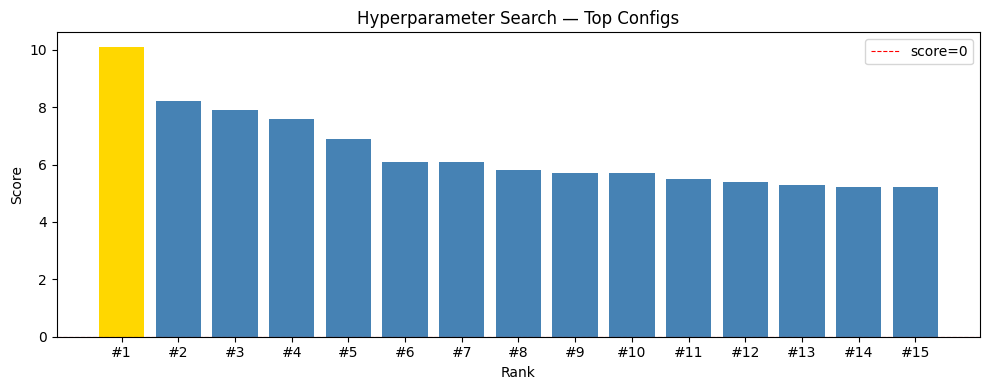

In [15]:
all_results = grid_results + random_results
all_results.sort(key=lambda x: x['score'], reverse=True)

BEST_CFG   = all_results[0]['cfg']
BEST_SCORE = all_results[0]['score']

# Swap yolo_model to yolov8m for the final run
BEST_CFG_FINAL = {**BEST_CFG, **FIXED_CFG_FINAL}

print('=' * 60)
print('🏆 BEST CONFIG FOUND (search phase)')
print('=' * 60)
print(f'Score: {BEST_SCORE:.4f}')
for k, v in BEST_CFG.items():
    print(f'  {k:22s}: {v}')

print()
print('Final run will use:')
for k, v in BEST_CFG_FINAL.items():
    print(f'  {k:22s}: {v}')

# Summary table
rows = []
for r in all_results[:15]:
    row = {'score': round(r['score'], 4)}
    row.update(r['metrics'])
    row.update({k: v for k, v in r['cfg'].items() if k not in FIXED_CFG_SEARCH})
    rows.append(row)
df = pd.DataFrame(rows)
print('\nTop-15 results:')
display(df)

fig, ax = plt.subplots(figsize=(10, 4))
scores = [r['score'] for r in all_results[:15]]
labels = [f'#{i+1}' for i in range(len(scores))]
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(scores))]
ax.bar(labels, scores, color=colors)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8, label='score=0')
ax.set_xlabel('Rank'); ax.set_ylabel('Score')
ax.set_title('Hyperparameter Search — Top Configs')
ax.legend(); plt.tight_layout(); plt.show()

## 📥 Cell 16 — Download Search Results (CSV & Excel)

In [16]:
import datetime
from google.colab import files as colab_files

search_rows = []
for rank, r in enumerate(all_results, start=1):
    row = {
        'rank':        rank,
        'search_type': 'grid' if r in grid_results else 'random',
        'score':       round(r['score'], 6),
    }
    for k, v in r['cfg'].items():
        row[f'cfg_{k}'] = v
    for k, v in r['metrics'].items():
        row[f'metric_{k}'] = v
    search_rows.append(row)

df_search = pd.DataFrame(search_rows)
print('All search results:')
display(df_search)

ts = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

csv_path = f'/content/search_results_{ts}.csv'
df_search.to_csv(csv_path, index=False)
print(f'\n✅ CSV saved → {csv_path}')

xlsx_path = f'/content/search_results_{ts}.xlsx'
try:
    with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
        df_search.to_excel(writer, sheet_name='All Results', index=False)
        pd.DataFrame([{'parameter': k, 'value': v}
                      for k, v in BEST_CFG_FINAL.items()]).to_excel(
            writer, sheet_name='Best Config', index=False)
        grid_rows = [r for r in search_rows if r['search_type'] == 'grid']
        pd.DataFrame(grid_rows).to_excel(writer, sheet_name='Grid Search', index=False)
        rand_rows = [r for r in search_rows if r['search_type'] == 'random']
        pd.DataFrame(rand_rows).to_excel(writer, sheet_name='Random Search', index=False)

        from openpyxl.utils import get_column_letter
        from openpyxl.styles import PatternFill, Font
        gold = PatternFill('solid', fgColor='FFD700')
        bold = Font(bold=True)
        for sn in writer.sheets:
            ws = writer.sheets[sn]
            for col in ws.columns:
                ml = max((len(str(c.value)) for c in col if c.value), default=8)
                ws.column_dimensions[get_column_letter(col[0].column)].width = min(ml+4, 30)
            for cell in ws[1]: cell.font = bold
        for cell in writer.sheets['All Results'][2]: cell.fill = gold

    print(f'✅ Excel saved → {xlsx_path}')
except Exception as e:
    print(f'⚠️  Excel failed ({e}). CSV still available.')
    xlsx_path = None

print('\nDownloading CSV...')
colab_files.download(csv_path)
if xlsx_path and os.path.exists(xlsx_path):
    print('Downloading Excel...')
    colab_files.download(xlsx_path)
print('\n✅ Done.')

All search results:


,rank,search_type,score,cfg_conf_thr,cfg_sim_thr,cfg_min_track_frames,cfg_iou_thr,cfg_max_lost,cfg_frame_skip,cfg_entry_y,cfg_exit_y,cfg_yolo_model,metric_total_persons,metric_total_entries,metric_total_exits,metric_revisit_persons,metric_frames_processed
0,1,random,10.1,0.595,0.937,8,0.261,16,4,0.35,0.65,yolov8n.pt,6,9,2,3,1302
1,2,grid,8.2,0.350,0.840,4,0.500,35,5,0.35,0.65,yolov8n.pt,8,7,2,2,1302
2,3,grid,7.9,0.550,0.900,6,0.400,50,5,0.35,0.65,yolov8n.pt,7,7,2,2,1302
3,4,random,7.6,0.597,0.843,6,0.520,39,5,0.35,0.65,yolov8n.pt,6,9,2,2,1302
4,5,grid,6.9,0.550,0.900,4,0.300,50,3,0.35,0.65,yolov8n.pt,8,9,5,1,1302
5,6,grid,6.1,0.350,0.840,6,0.300,50,3,0.35,0.65,yolov8n.pt,8,8,3,1,1302
6,7,random,6.1,0.532,0.828,6,0.331,15,3,0.35,0.65,yolov8n.pt,8,8,3,1,1302
7,8,grid,5.8,0.450,0.780,4,0.300,50,4,0.35,0.65,yolov8n.pt,7,7,3,1,1302
8,9,grid,5.7,0.350,0.840,4,0.300,50,5,0.35,0.65,yolov8n.pt,8,8,2,1,1302
9,10,random,5.7,0.415,0.877,7,0.532,35,4,0.35,0.65,yolov8n.pt,8,7,2,1,1302



✅ CSV saved → /content/search_results_20260415_061646.csv
✅ Excel saved → /content/search_results_20260415_061646.xlsx



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Done.


## 🎬 Cell 17 — Final Run with Best Config
Uses **yolov8m + full TTA** for maximum accuracy.
Person count should now reflect the real number of people in your video.

In [17]:
print('Running FINAL pipeline...')
print('Config:', BEST_CFG_FINAL)
print('-' * 60)

final = run_pipeline(VIDEO_PATH, BEST_CFG_FINAL, verbose=True,
                     yolo_model=YOLO_FINAL, fast_tta=False)

print('\n' + '=' * 60)
print('FINAL RESULTS')
print('=' * 60)
m = final['metrics']
print(f"  Unique persons detected : {m['total_persons']}")
print(f"  Total entry events      : {m['total_entries']}")
print(f"  Total exit events       : {m['total_exits']}")
print(f"  Persons with revisits   : {m['revisit_persons']}")
print(f"  Frames processed        : {m['frames_processed']}")
print(f"  Pipeline score          : {final['score']:.4f}")
print()

if m['total_persons'] > MAX_PERSONS_EXPECTED:
    print(f'⚠️  Still seeing {m["total_persons"]} unique IDs (expected ≤{MAX_PERSONS_EXPECTED}).')
    print('   Suggestions:')
    print('   1. Increase conf_thr in BEST_CFG_FINAL (e.g. 0.55)')
    print('   2. Increase sim_thr (e.g. 0.88–0.92)')
    print('   3. Increase MERGE_SIM_THRESHOLD in Cell 2 (e.g. 0.85)')
    print('   4. Verify MAX_PERSONS_EXPECTED matches your scene.')
else:
    print(f'✅ Person count looks correct: {m["total_persons"]} unique IDs.')

Running FINAL pipeline...
Config: {'conf_thr': 0.595, 'sim_thr': 0.937, 'min_track_frames': 8, 'iou_thr': 0.261, 'max_lost': 16, 'frame_skip': 4, 'entry_y': 0.35, 'exit_y': 0.65, 'yolo_model': 'yolov8m.pt'}
------------------------------------------------------------
  Frame 1300/1302 (100%)  | Persons known: 6
🟢 ENTERED — Person #1 | Frame 44
🟢 ENTERED — Person #2 | Frame 224
🟢 ENTERED — Person #3 | Frame 260
🟢 ENTERED — Person #4 | Frame 300
🔴 EXITED — Person #4 | Frame 380
🟢 ENTERED — Person #5 | Frame 488
🟢 ENTERED — Person #6 | Frame 652
🟢 ENTERED — Person #7 | Frame 716
🟢 ENTERED — Person #8 | Frame 760
🟢 ENTERED — Person #9 | Frame 968
🟢 ENTERED — Person #10 | Frame 1116
🔴 EXITED — Person #10 | Frame 1140

FINAL RESULTS
  Unique persons detected : 6
  Total entry events      : 10
  Total exit events       : 2
  Persons with revisits   : 4
  Frames processed        : 1302
  Pipeline score          : 12.6000

✅ Person count looks correct: 6 unique IDs.


## 📊 Cell 18 — Analytics & Identity Table

Person Identity Table:


,person_id,first_seen,last_seen,visit_count,stored_embs,re_identified
0,1,32,104,2,20,True
1,2,212,320,2,20,True
2,3,248,1248,1,20,False
3,4,288,448,2,20,True
4,5,476,520,2,20,True
5,6,640,676,1,4,False



Event Log (last 30):


,frame,person_id,event
0,44,1,ENTERED
1,224,2,ENTERED
2,260,3,ENTERED
3,300,4,ENTERED
4,380,4,EXITED
5,488,5,ENTERED
6,652,6,ENTERED
7,716,7,ENTERED
8,760,8,ENTERED
9,968,9,ENTERED


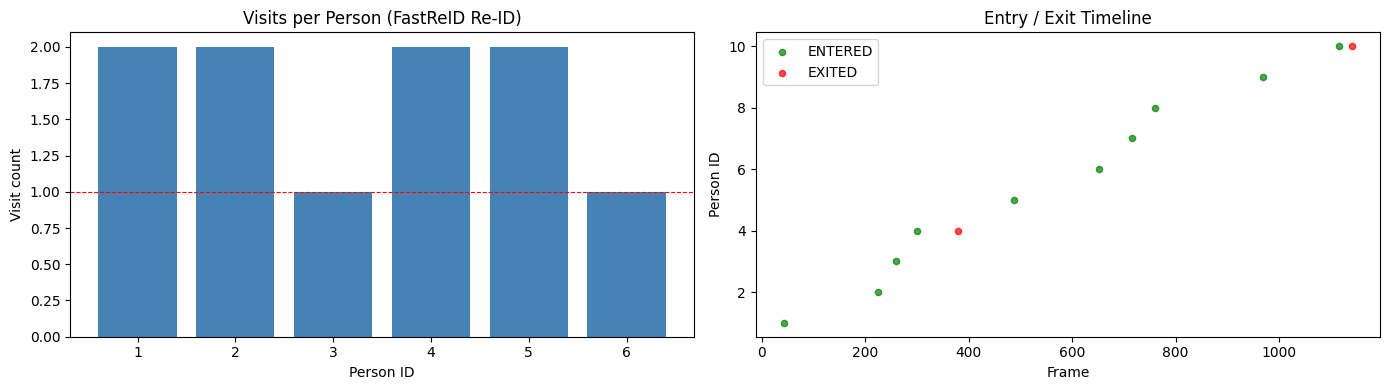

In [18]:
db  = final['database']
evs = final['event_log']

rows = []
for pid, rec in sorted(db.items()):
    rows.append({
        'person_id':     pid,
        'first_seen':    rec.get('first_seen', '?'),
        'last_seen':     rec.get('last_seen', '?'),
        'visit_count':   rec.get('visit_count', 0),
        'stored_embs':   len(rec.get('embeddings', [])),
        're_identified': rec.get('visit_count', 0) > 1,
    })

df_persons = pd.DataFrame(rows)
print('Person Identity Table:')
display(df_persons)

if evs:
    df_events = pd.DataFrame(evs)
    print('\nEvent Log (last 30):')
    display(df_events.tail(30))

if rows:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    pids_   = [r['person_id']  for r in rows]
    visits_ = [r['visit_count'] for r in rows]
    axes[0].bar([str(p) for p in pids_], visits_, color='steelblue')
    axes[0].set_xlabel('Person ID'); axes[0].set_ylabel('Visit count')
    axes[0].set_title('Visits per Person (FastReID Re-ID)')
    axes[0].axhline(1, color='red', linestyle='--', linewidth=0.8)

    if evs:
        df_ev = pd.DataFrame(evs)
        for evt, color in [('ENTERED','green'),('EXITED','red')]:
            sub = df_ev[df_ev['event']==evt]
            axes[1].scatter(sub['frame'], sub['person_id'],
                            label=evt, c=color, alpha=0.7, s=20)
        axes[1].set_xlabel('Frame'); axes[1].set_ylabel('Person ID')
        axes[1].set_title('Entry / Exit Timeline'); axes[1].legend()

    plt.tight_layout(); plt.show()

## 💾 Cell 19 — Download Final Output Video

In [19]:
import subprocess, shutil
from google.colab import files

out_raw  = final['output_path']
out_h264 = out_raw.replace('.mp4', '_h264.mp4')

if shutil.which('ffmpeg'):
    subprocess.run(
        ['ffmpeg', '-y', '-i', out_raw,
         '-vcodec', 'libx264', '-crf', '23', '-preset', 'fast', out_h264],
        check=False, capture_output=True)
    download_path = out_h264 if os.path.exists(out_h264) else out_raw
else:
    download_path = out_raw

print(f'Downloading: {download_path}')
files.download(download_path)

Downloading: MicrosoftTeams-video_reid_out_h264.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔧 Cell 20 — Manual Config Run
Useful for quick targeted experiments with specific parameters.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
#  ✏️  EDIT BELOW — then run this cell
# ══════════════════════════════════════════════════════════════════════════════
MANUAL_CFG = {
    # ── Detection ──────────────────────────────────────────────────────────────
    'conf_thr':          0.45,   # YOLO confidence threshold (higher = fewer ghosts)
    'yolo_model':        'yolov8m.pt',

    # ── Re-ID ──────────────────────────────────────────────────────────────────
    'sim_thr':           0.84,   # cosine threshold (higher = stricter re-ID)

    # ── Tracker ────────────────────────────────────────────────────────────────
    'iou_thr':           0.40,
    'max_lost':          30,
    'min_track_frames':  5,

    # ── Speed / zones ──────────────────────────────────────────────────────────
    'frame_skip':        2,      # 1 = all frames, 2 = half, 3 = third
    'entry_y':           0.35,
    'exit_y':            0.65,
}
# Use yolov8m for manual runs (comment out and pass YOLO_FAST for speed)
MANUAL_YOLO = YOLO_FINAL

import subprocess, shutil, datetime
from google.colab import files as colab_files

print('📋 Running manual config:')
for k, v in MANUAL_CFG.items():
    print(f'   {k:22s}: {v}')
print('-' * 60)

manual_result = run_pipeline(VIDEO_PATH, MANUAL_CFG, verbose=True,
                             yolo_model=MANUAL_YOLO, fast_tta=False)

print('\n' + '=' * 60)
print('MANUAL RUN RESULTS')
print('=' * 60)
m = manual_result['metrics']
print(f"  Unique persons detected : {m['total_persons']}")
print(f"  Total entry events      : {m['total_entries']}")
print(f"  Total exit events       : {m['total_exits']}")
print(f"  Persons with revisits   : {m['revisit_persons']}")
print(f"  Frames processed        : {m['frames_processed']}")
print(f"  Pipeline score          : {manual_result['score']:.4f}")

db_m   = manual_result['database']
rows_m = [
    {'person_id': pid, 'first_seen': rec.get('first_seen','?'),
     'last_seen': rec.get('last_seen','?'),
     'visit_count': rec.get('visit_count',0),
     'stored_embs': len(rec.get('embeddings',[])),
     're_identified': rec.get('visit_count',0) > 1}
    for pid, rec in sorted(db_m.items())
]
if rows_m:
    print('\nPerson Identity Table:')
    display(pd.DataFrame(rows_m))

manual_raw  = manual_result['output_path']
ts_m        = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
manual_h264 = manual_raw.replace('.mp4', f'_manual_{ts_m}_h264.mp4')

if shutil.which('ffmpeg'):
    proc = subprocess.run(
        ['ffmpeg', '-y', '-i', manual_raw,
         '-vcodec', 'libx264', '-crf', '23', '-preset', 'fast', manual_h264],
        capture_output=True, text=True)
    dl = manual_h264 if proc.returncode == 0 and os.path.exists(manual_h264) else manual_raw
else:
    dl = manual_raw

print(f'\nDownloading: {dl}')
colab_files.download(dl)
print('✅ Done.')

📋 Running manual config:
   conf_thr              : 0.45
   yolo_model            : yolov8m.pt
   sim_thr               : 0.84
   iou_thr               : 0.4
   max_lost              : 30
   min_track_frames      : 5
   frame_skip            : 2
   entry_y               : 0.35
   exit_y                : 0.65
------------------------------------------------------------
  Frame 1300/1302 (100%)  | Persons known: 8
🟢 ENTERED — Person #1 | Frame 16
🟢 ENTERED — Person #2 | Frame 198
🟢 ENTERED — Person #3 | Frame 232
🟢 ENTERED — Person #4 | Frame 268
🔴 EXITED — Person #3 | Frame 400
🟢 ENTERED — Person #5 | Frame 462
🟢 ENTERED — Person #6 | Frame 626
🟢 ENTERED — Person #7 | Frame 690
🔴 EXITED — Person #7 | Frame 704
🟢 ENTERED — Person #8 | Frame 770
🔴 EXITED — Person #5 | Frame 1134

MANUAL RUN RESULTS
  Unique persons detected : 8
  Total entry events      : 8
  Total exit events       : 3
  Persons with revisits   : 0
  Frames processed        : 1302
  Pipeline score          : 3.6000

Pers

,person_id,first_seen,last_seen,visit_count,stored_embs,re_identified
0,1,10,110,1,20,False
1,2,192,320,1,20,False
2,3,226,1270,1,20,False
3,4,262,374,1,20,False
4,5,456,1248,1,20,False
5,6,620,678,1,8,False
6,7,684,1058,1,20,False
7,8,764,794,1,8,False



Downloading: MicrosoftTeams-video_reid_out_manual_20260415_061806_h264.mp4


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done.
